In [1]:
#importing the libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [91]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [3]:
import warnings
warnings.filterwarnings('ignore')

In [4]:
!pip3 install -U ucimlrepo

In [5]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_prognostic = fetch_ucirepo(id=16)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_prognostic.data.features
y = breast_cancer_wisconsin_prognostic.data.targets

# metadata
print(breast_cancer_wisconsin_prognostic.metadata)

# variable information
print(breast_cancer_wisconsin_prognostic.variables)


{'uci_id': 16, 'name': 'Breast Cancer Wisconsin (Prognostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/16/breast+cancer+wisconsin+prognostic', 'data_url': 'https://archive.ics.uci.edu/static/public/16/data.csv', 'abstract': 'Prognostic Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 198, 'num_features': 33, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Outcome'], 'index_col': ['ID'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1995, 'last_updated': 'Sun Jan 14 2024', 'dataset_doi': '10.24432/C5GK50', 'creators': ['William Wolberg', 'W. Street', 'Olvi Mangasarian'], 'intro_paper': None, 'additional_info': {'summary': 'Each record represents follow-up data for one breast cancer case.  These are consecutive patients seen by Dr. Wolberg since 1984, and include only those cases exhibiting invasive brea

In [6]:
X.head(20)

,Time,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,tumor_size,lymph_node_status
0,31,18.02,27.60,117.50,1013.0,0.09489,0.10360,0.10860,0.07055,0.1865,...,139.70,1436.0,0.1195,0.1926,0.3140,0.11700,0.2677,0.08113,5.0,5.0
1,61,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,3.0,2.0
2,116,21.37,17.44,137.50,1373.0,0.08836,0.11890,0.12550,0.08180,0.2333,...,159.10,1949.0,0.1188,0.3449,0.3414,0.20320,0.4334,0.09067,2.5,0.0
3,123,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,2.0,0.0
4,27,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,3.5,0.0
5,77,12.75,15.29,84.60,502.7,0.11890,0.15690,0.16640,0.07666,0.1995,...,107.30,733.2,0.1706,0.4196,0.5999,0.17090,0.3485,0.11790,2.5,0.0
6,60,18.98,19.61,124.40,1112.0,0.09087,0.12370,0.12130,0.08910,0.1727,...,152.60,1593.0,0.1144,0.3371,0.2990,0.19220,0.2726,0.09581,1.5,NaN
7,77,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,4.0,10.0
8,119,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,2.0,1.0
9,76,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,6.0,20.0


In [7]:
y.head(10)

,Outcome
0,N
1,N
2,N
3,N
4,R
5,R
6,N
7,R
8,N
9,N


In [8]:
X.shape

(198, 33)

In [9]:
missing_data=X.isnull().sum()
print(missing_data)

Time                  0
radius1               0
texture1              0
perimeter1            0
area1                 0
smoothness1           0
compactness1          0
concavity1            0
concave_points1       0
symmetry1             0
fractal_dimension1    0
radius2               0
texture2              0
perimeter2            0
area2                 0
smoothness2           0
compactness2          0
concavity2            0
concave_points2       0
symmetry2             0
fractal_dimension2    0
radius3               0
texture3              0
perimeter3            0
area3                 0
smoothness3           0
compactness3          0
concavity3            0
concave_points3       0
symmetry3             0
fractal_dimension3    0
tumor_size            0
lymph_node_status     4
dtype: int64


In [10]:
data_with_missing = X[X.isnull().any(axis=1)]
X.dropna(inplace=True)

In [11]:
missing_data=y.isnull().sum()
print(missing_data)

Outcome    0
dtype: int64


In [12]:
X.describe()

,Time,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,tumor_size,lymph_node_status
count,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,...,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000,194.000000
mean,46.938144,17.402320,22.300979,114.781495,969.092268,0.102774,0.142642,0.156309,0.086808,0.192885,...,140.136907,1401.756701,0.143921,0.364567,0.436010,0.178449,0.322251,0.090777,2.867526,3.211340
std,34.523646,3.171672,4.335292,21.430694,353.159959,0.012607,0.050229,0.070942,0.033962,0.027679,...,28.826843,587.040705,0.022092,0.165528,0.174757,0.045529,0.074068,0.021371,1.950588,5.479276
min,1.000000,10.950000,10.380000,71.900000,361.600000,0.074970,0.046050,0.023980,0.020310,0.130800,...,85.100000,508.100000,0.081910,0.051310,0.023980,0.028990,0.156500,0.055040,0.400000,0.000000
25%,14.250000,15.052500,19.342500,98.160000,702.525000,0.093900,0.109850,0.106075,0.063760,0.174075,...,117.925000,940.575000,0.129325,0.247550,0.322150,0.152225,0.275950,0.076368,1.500000,0.000000
50%,39.500000,17.290000,21.795000,113.700000,929.100000,0.102200,0.131750,0.152050,0.086075,0.189350,...,136.500000,1295.000000,0.141750,0.350450,0.401150,0.178500,0.310300,0.086540,2.500000,1.000000
75%,73.000000,19.580000,24.782500,129.650000,1193.500000,0.111375,0.172200,0.200500,0.103925,0.209550,...,159.875000,1694.250000,0.154450,0.423675,0.550175,0.207125,0.358475,0.101775,3.500000,4.000000
max,125.000000,27.220000,39.280000,182.100000,2250.000000,0.144700,0.311400,0.426800,0.201200,0.304000,...,232.200000,3903.000000,0.222600,1.058000,1.170000,0.290300,0.663800,0.207500,10.000000,27.000000


In [13]:
y.describe()

,Outcome
count,198
unique,2
top,N
freq,151


In [14]:
X.columns

Index(['Time', 'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'compactness1', 'concavity1', 'concave_points1', 'symmetry1',
       'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2',
       'smoothness2', 'compactness2', 'concavity2', 'concave_points2',
       'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3',
       'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3',
       'symmetry3', 'fractal_dimension3', 'tumor_size', 'lymph_node_status'],
      dtype='object')

In [15]:
# X = X.drop(columns=['Time'])


In [33]:
display(X.head())

,Time,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,...,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,tumor_size,lymph_node_status
0,31,18.02,27.60,117.50,1013.0,0.09489,0.1036,0.1086,0.07055,0.1865,...,139.70,1436.0,0.1195,0.1926,0.3140,0.1170,0.2677,0.08113,5.0,5.0
1,61,17.99,10.38,122.80,1001.0,0.11840,0.2776,0.3001,0.14710,0.2419,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,3.0,2.0
2,116,21.37,17.44,137.50,1373.0,0.08836,0.1189,0.1255,0.08180,0.2333,...,159.10,1949.0,0.1188,0.3449,0.3414,0.2032,0.4334,0.09067,2.5,0.0
3,123,11.42,20.38,77.58,386.1,0.14250,0.2839,0.2414,0.10520,0.2597,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,2.0,0.0
4,27,20.29,14.34,135.10,1297.0,0.10030,0.1328,0.1980,0.10430,0.1809,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,3.5,0.0


In [17]:
y.columns

Index(['Outcome'], dtype='object')

In [18]:
#Encode Categorical Variables
le = LabelEncoder()
for col in y.columns:
    y[col] = le.fit_transform(y[col])

y.head()

,Outcome
0,0
1,0
2,0
3,0
4,1


<Axes: xlabel='Outcome', ylabel='count'>

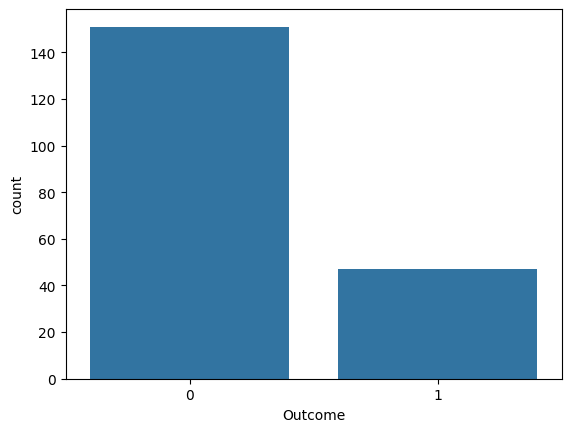

In [19]:
sns.countplot(x=y['Outcome'])

<Axes: xlabel='Outcome', ylabel='area3'>

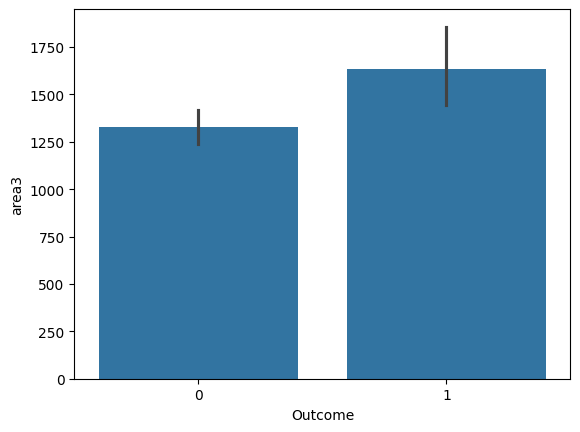

In [20]:
sns.barplot(x=y['Outcome'], y=X['area3'])

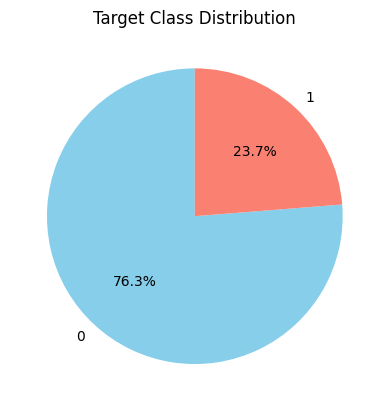

In [21]:
class_counts = y['Outcome'].value_counts()

class_counts.plot.pie(autopct='%1.1f%%', startangle=90, colors=['skyblue', 'salmon'])
plt.title('Target Class Distribution')
plt.ylabel('')
plt.show()

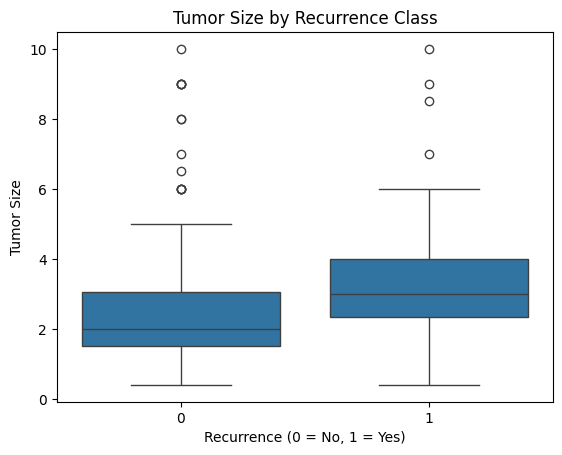

In [22]:
sns.boxplot(x=y['Outcome'], y=X['tumor_size'])
plt.title('Tumor Size by Recurrence Class')
plt.xlabel('Recurrence (0 = No, 1 = Yes)')
plt.ylabel('Tumor Size')
plt.show()

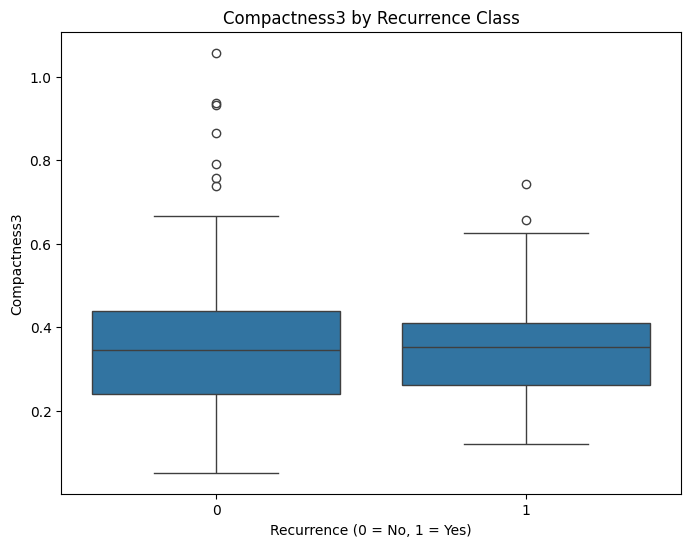

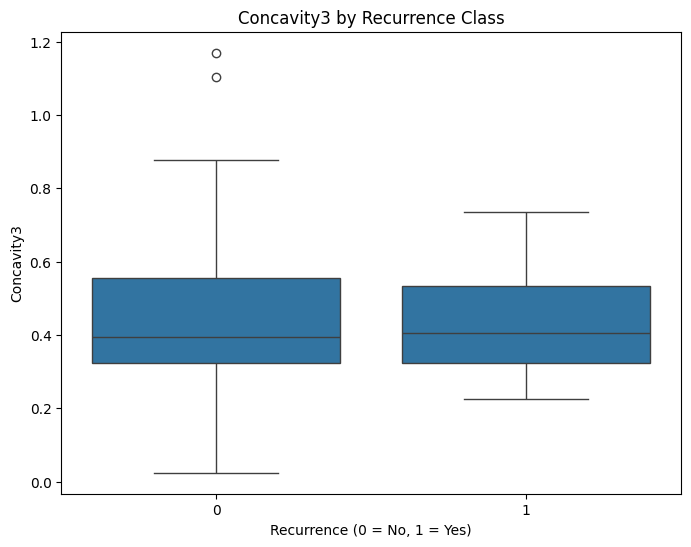

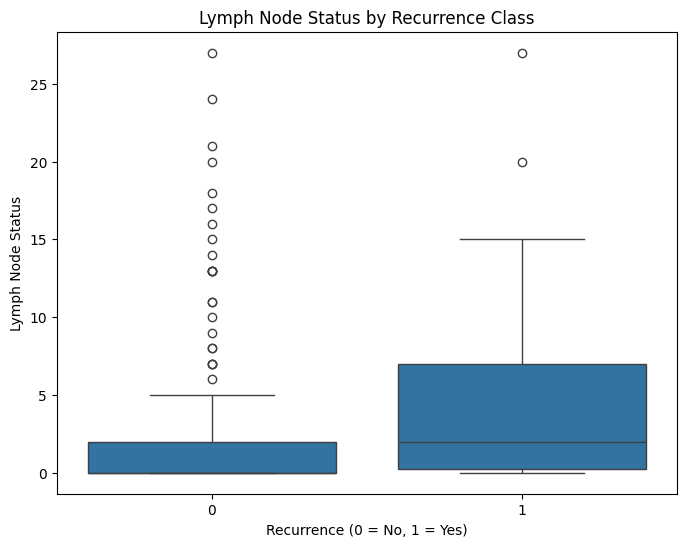

In [23]:
#box plot for 'compactness3' and 'Outcome'
plt.figure(figsize=(8, 6))
sns.boxplot(x=y['Outcome'], y=X['compactness3'])
plt.title('Compactness3 by Recurrence Class')
plt.xlabel('Recurrence (0 = No, 1 = Yes)')
plt.ylabel('Compactness3')
plt.show()

#box plot for 'concavity3' and 'Outcome'
plt.figure(figsize=(8, 6))
sns.boxplot(x=y['Outcome'], y=X['concavity3'])
plt.title('Concavity3 by Recurrence Class')
plt.xlabel('Recurrence (0 = No, 1 = Yes)')
plt.ylabel('Concavity3')
plt.show()

#box plot for 'lymph_node_status' and 'Outcome'
plt.figure(figsize=(8, 6))
sns.boxplot(x=y['Outcome'], y=X['lymph_node_status'])
plt.title('Lymph Node Status by Recurrence Class')
plt.xlabel('Recurrence (0 = No, 1 = Yes)')
plt.ylabel('Lymph Node Status')
plt.show()

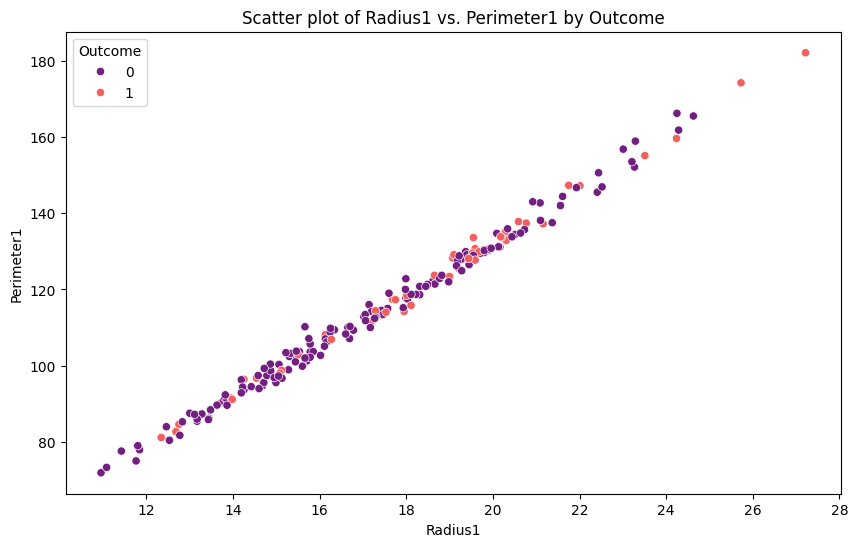

In [24]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X['radius1'], y=X['perimeter1'], hue=y['Outcome'], palette='magma', hue_order=[0, 1])
plt.title('Scatter plot of Radius1 vs. Perimeter1 by Outcome')
plt.xlabel('Radius1')
plt.ylabel('Perimeter1')
# plt.legend(title='Outcome', labels=['No Recurrence', 'Recurrence']) # Removed manual legend call
plt.show()

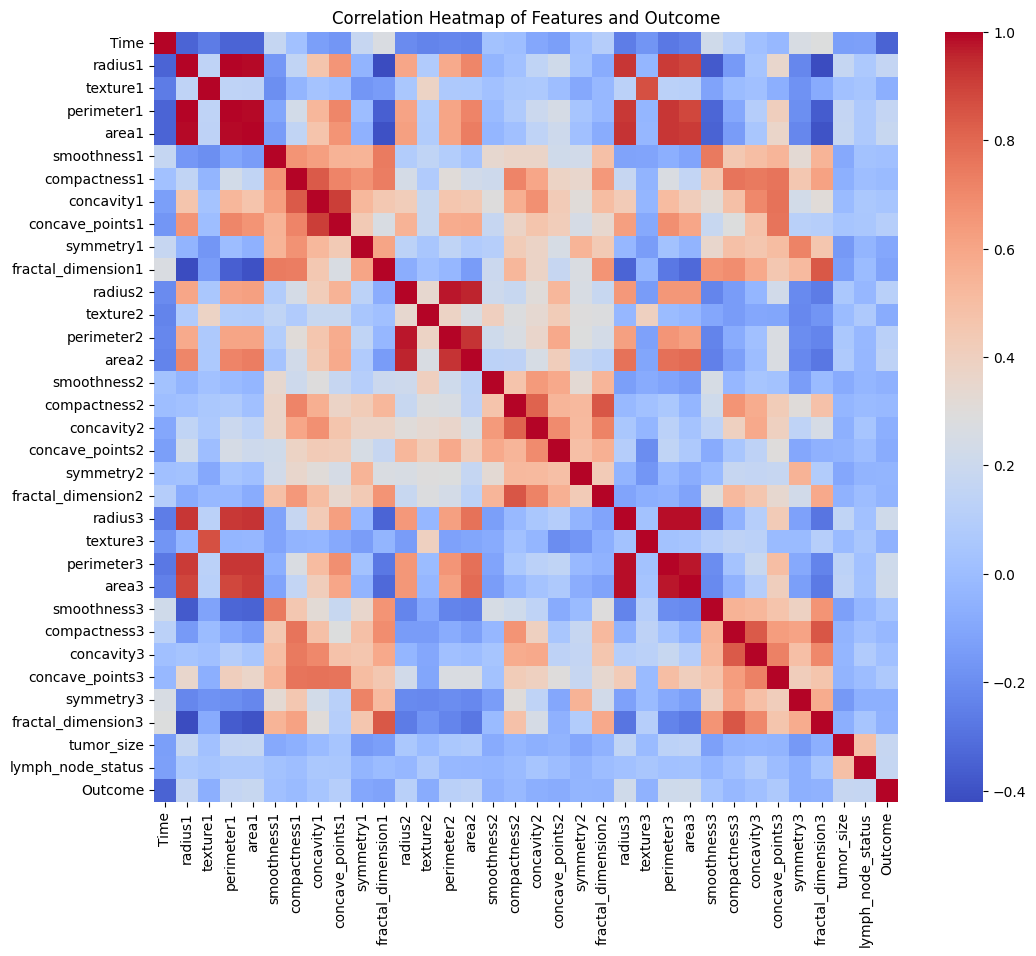

In [25]:
# Concatenate X and y to include the target variable in the correlation analysis
data = pd.concat([X, y], axis=1)

# Calculate the correlation matrix
correlation_matrix = data.corr()

# Generate a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title('Correlation Heatmap of Features and Outcome')
plt.show()

<Figure size 1000x600 with 0 Axes>

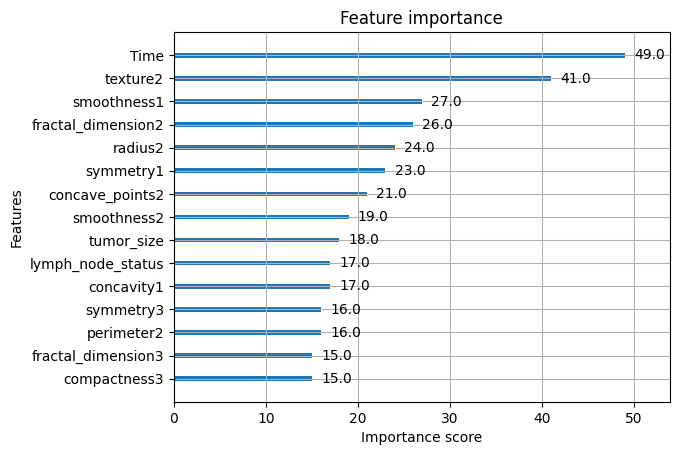

               Feature  Importance
18             radius3    0.087431
0                 Time    0.083105
4                area1    0.080897
27   lymph_node_status    0.065049
16     concave_points2    0.063291
11            texture2    0.047180
1              radius1    0.045851
15        compactness2    0.039462
23          concavity3    0.038366
5          smoothness1    0.037458
10             radius2    0.036053
6           concavity1    0.033702
17  fractal_dimension2    0.032314
19            texture3    0.031751
24           symmetry3    0.030386
25  fractal_dimension3    0.028152
8            symmetry1    0.027378
7      concave_points1    0.027080
26          tumor_size    0.026071
14         smoothness2    0.025408
2             texture1    0.023876
3           perimeter1    0.022041
12          perimeter2    0.020818
20          perimeter3    0.016744
22        compactness3    0.015463
9   fractal_dimension1    0.005887
13               area2    0.005522
21               are

In [54]:
from xgboost import XGBClassifier, plot_importance
import matplotlib.pyplot as plt
import pandas as pd

xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X, y)

# Get feature importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': xgb.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10,6))
plot_importance(xgb, importance_type='weight', max_num_features=15)
plt.show()

print(importance)


In [67]:
# Drop the least important features
# features_to_drop = ['smoothness3', 'concavity2', 'compactness1', 'symmetry2', 'concave_points3']
# X = X.drop(columns=features_to_drop)

print("Shape of X after dropping features:", X.shape)
display(X.head())

Shape of X after dropping features: (194, 28)


,Time,radius1,texture1,perimeter1,area1,smoothness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,compactness3,concavity3,symmetry3,fractal_dimension3,tumor_size,lymph_node_status
0,31,18.02,27.60,117.50,1013.0,0.09489,0.1086,0.07055,0.1865,0.06333,...,21.63,37.08,139.70,1436.0,0.1926,0.3140,0.2677,0.08113,5.0,5.0
1,61,17.99,10.38,122.80,1001.0,0.11840,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.6656,0.7119,0.4601,0.11890,3.0,2.0
2,116,21.37,17.44,137.50,1373.0,0.08836,0.1255,0.08180,0.2333,0.06010,...,24.90,20.98,159.10,1949.0,0.3449,0.3414,0.4334,0.09067,2.5,0.0
3,123,11.42,20.38,77.58,386.1,0.14250,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.8663,0.6869,0.6638,0.17300,2.0,0.0
4,27,20.29,14.34,135.10,1297.0,0.10030,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.2050,0.4000,0.2364,0.07678,3.5,0.0


In [73]:
X.columns

Index(['Time', 'radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1',
       'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1',
       'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2',
       'compactness2', 'concave_points2', 'fractal_dimension2', 'radius3',
       'texture3', 'perimeter3', 'area3', 'compactness3', 'concavity3',
       'symmetry3', 'fractal_dimension3', 'tumor_size', 'lymph_node_status'],
      dtype='object')

In [57]:
# Align y to the index of the cleaned X
y = y.loc[X.index]

#Splitting the data into training and testing data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(155, 28)
(39, 28)
(155, 1)
(39, 1)


In [27]:
#sc = StandardScaler()
#X_train = sc.fit_transform(X_train)
#X_test = sc.transform(X_test)

In [58]:
# Creating and training the Logistic Regression model
lr = LogisticRegression()
lr_pred = lr.fit(X, y).predict(X_test)

In [59]:
rf = RandomForestClassifier(max_depth=2,random_state=0)
rf_pred = rf.fit(X, y).predict(X_test)


In [60]:
models=['LR','RF']
preds=[lr_pred,rf_pred]
acc=[]
for i in preds:
    accscore=round(accuracy_score(i,y_test), 2)
    acc.append(accscore)
data=zip(models,acc)
scoresdf=pd.DataFrame(data,columns=['MODEL','ACCURACY SCORE'])
scoresdf

,MODEL,ACCURACY SCORE
0,LR,0.95
1,RF,0.87


In [75]:
#Logistic Regression
#Testing the model using the test data
lr_pred=lr.predict(X_test)

accuracy = accuracy_score(y_test, lr_pred)
conf_matrix = confusion_matrix(y_test, lr_pred)
class_report = classification_report(y_test, lr_pred)


print("Accuracy:", accuracy)
print("Confusion matrix:\n",conf_matrix)
print("Class report:\n",class_report)

Accuracy: 0.9487179487179487
Confusion matrix:
 [[31  1]
 [ 1  6]]
Class report:
               precision    recall  f1-score   support

           0       0.97      0.97      0.97        32
           1       0.86      0.86      0.86         7

    accuracy                           0.95        39
   macro avg       0.91      0.91      0.91        39
weighted avg       0.95      0.95      0.95        39



In [80]:
#Random Forest Classifier
#Testing the model using the test data
rf_pred=rf.predict(X_test)

accuracy = accuracy_score(y_test, rf_pred)
conf_matrix = confusion_matrix(y_test, rf_pred)
class_report = classification_report(y_test, rf_pred)


print("Accuracy:", accuracy)
print("Confusion matrix:\n",conf_matrix)
print("Class report:\n",class_report)

Accuracy: 0.8717948717948718
Confusion matrix:
 [[32  0]
 [ 5  2]]
Class report:
               precision    recall  f1-score   support

           0       0.86      1.00      0.93        32
           1       1.00      0.29      0.44         7

    accuracy                           0.87        39
   macro avg       0.93      0.64      0.69        39
weighted avg       0.89      0.87      0.84        39



In [77]:
#Testing the model using logistic regression
predicted_recurrence = lr.predict([[30,19.02,27.77,118.64,1013.24,0.14250,0.2414,0.0880, 0.2597,0.09744,1.095,24.45,119.26,1117.77,0.16250,0.57687,0.11880,0.3654,21.67,38.08,159.10,1436.0,0.3449,0.4000,0.6638,0.17300,6.6,0.0]])
print("Predicted Recurrence:", predicted_recurrence)



Predicted Recurrence: [0]


In [79]:
#Testing the model using random forest classifier
predicted_recurrence = rf.predict([[30,19.02,27.77,118.64,1013.24,0.14250,0.2414,0.0880, 0.2597,0.09744,1.095,24.45,119.26,1117.77,0.16250,0.57687,0.11880,0.3654,21.67,38.08,159.10,1436.0,0.3449,0.4000,0.6638,0.17300,6.6,0.0]])
print("Predicted Recurrence:", predicted_recurrence)



Predicted Recurrence: [0]


In [96]:
# 1. Clone the repository
# This downloads a copy of your GitHub repository to the Colab runtime environment.
#!git clone https://github.com/I-muhithe/Breast_Cancer_Prognostic.git
# 2. Navigate to the repository directory
# The directory is named after the repository.
%cd Breast_Cancer_Prognostic
# 3. Configure Git Identity
# Replace with your actual GitHub email and username.
!git config user.email "ivykibanya@gmail.com"
!git config user.name "I-muhithe"
# 4. Add the notebook file
# Replace 'your_notebook_name.ipynb' with the exact name of your Colab file.
!git add Breast_Cancer_Prognostic.ipynb

# (Optional: Add all modified files)
# !git add .
# 5. Commit the changes
# Write a descriptive commit message.
!git commit -m "Initial commit of the Breast Cancer Prognostic."
# 6. Push the changes to GitHub
# You will be prompted to enter your GitHub username and the Personal Access Token (PAT).
# Note: The default branch is typically 'main' now, but use 'master' if your repository is older.
!git push origin main

[Errno 2] No such file or directory: 'Breast_Cancer_Prognostic'
/content/Breast_Cancer_Prognostic/Breast_Cancer_Prognostic/Breast_Cancer_Prognostic
fatal: pathspec 'Breast_Cancer_Prognostic.ipynb' did not match any files
On branch main

Initial commit

nothing to commit (create/copy files and use "git add" to track)
error: src refspec main does not match any
error: failed to push some refs to 'https://github.com/I-muhithe/Breast_Cancer_Prognostic.git'
